# Agentic Rag
1. It consists of Rag + Autonomous Agent
2. Here Rag acts like an external data source which may consist of external API, Vector DB or any Normal DB
3. While an autonomous agent makes intelligent decisions about the retrieval and generation.
    
    -> It decides when to retrieve info
    
    -> When to retrieve
    
    -> What to retrieve
    
    -> How many times to retrieve

#### Install & Import Dependencies

In [1]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.9/343.9 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.7/140.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/

1. 2nd line import `typed_dict` & `List` from typing module which is used for type hinting
2. 3rd line we import `StateGraph` and `END` where stategraph is used to define stateful cyclic graphs for making and handling LLM Calls and END is used to terminate graph execution
3. 4th line we `OpenAI` dependencies to use further if we use Chatgpt API's
4. 5th line we use to import `FAISS` vector store since its used for small size datasets
5. We use `RecursiveTextSplitter` here as text splitter
6. We import `Document` to define any schemas

In [11]:
import os
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

Create .env in main folder and put GROQ_API_KEY there

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [4]:
!pip install -q langchain-groq
from langchain_groq import ChatGroq

llm = ChatGroq(model_name="llama-3.3-70b-versatile",
temperature=0.2)

In [5]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7ea4afecbd10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7ea4afce8320>, model_name='llama-3.3-70b-versatile', temperature=0.2, model_kwargs={}, groq_api_key=SecretStr('**********'))

### State Definition

For STATE we decide vars via,
1. We store answer which is our result and query as question. Thus both as strings
2. We store the list of retrieved docs
3. Also we store a boolen var for deciding to retrieve or not

In [12]:
class AgentState(TypedDict):
  question: str
  answer: str
  documents: List[Document]
  needs_retrieve: bool

For embeddings we use hf sentence transformers

In [14]:
!pip install langchain-huggingface sentence-transformers

In [15]:
# Local execution (Requires: pip install langchain-huggingface sentence-transformers)
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [16]:
### Sample Document And VectorStore
# Sample documents for demonstration
sample_texts = [
    "LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner.",
    "RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate responses.",
    "Vector databases store high-dimensional vectors and enable efficient similarity search. They are commonly used in RAG systems to find relevant documents based on semantic similarity.",
    "Agentic systems are AI systems that can take actions, make decisions, and interact with their environment autonomously. They often use planning and reasoning capabilities."
]

documents=[Document(page_content=text) for text in sample_texts]

##create vector store
vectorstore = FAISS.from_documents(documents, embeddings)
retriever = vectorstore.as_retriever(k=3)

### Agent Functions

Here we have did the following things,
1. So for i/p arg and o/p args we fetch AgentState since we need to fetch question from it and update the need_retrieval value as well as return the state
2. Also we fetch question from state, and then check if it contains the respective keywords
3. If it contains any then we agent retrieves the context

In [27]:
def decide_retrieval(state: AgentState) -> AgentState:
    """
    Decide if we need to retrieve documents based on the question
    """
    question = state["question"]

    # Simple heuristic: if question contains certain keywords, retrieve
    retrieval_keywords = ["what", "how", "explain", "describe", "tell me"]
    needs_retrieval = any(keyword in question.lower() for keyword in retrieval_keywords)

    return {**state, "needs_retrieval": needs_retrieval}

We define the retrieve document function here and invoke is used to retrieve relevatn context

Then in the agent state we update the document list to the fetched documents

In [28]:
def retrieve_documents(state: AgentState) -> AgentState:
    """
    Retrieve relevant documents based on the question
    """
    question = state["question"]
    documents = retriever.invoke(question)

    return {**state, "documents": documents}

Here we do the following things,
1. First we get the question
2. Second we try to get the documents, if empty then let it be empty list or get the docs
3. if we get documents then pass the context in the prompt else just pass the question itself
4. At last invoke the llm and update the answer in the state

In [34]:
def generate_answer(state: AgentState)->AgentState:
  """
  Generate and store the answer in state
  """
  question=state["question"]
  documents=state.get("documents",[])

  if documents:
    context="\n\n".join([doc.page_content for doc in documents])
    prompt=f"""based on following context, answer the question

    context:{context}
    question:{question}
    Answer:
    """
  else:
    prompt=f"Answer the following question: {question}"

  response=llm.invoke(prompt)
  answer=response.content

  return {**state, "answer":answer}

### Conditional Logic

In [30]:
def should_retrieve(state: AgentState)->str:
  """
  Function to decide whether to retrieve context or generate data
  """
  if state["needs_retrieve"]:
    return "retrieve"
  else:
    return "generate"

### Build the graph

We have taken the following things here,
1. We fist define the state graph and store it as workflow
2. Then we add our 3 nodes and name them, also we add their respective agent functions
3. Then, we set the entry_point as decide
4. After decide we set the condition to decide based on should_retrieve answer as done below
5. At last we compile the workflow
6. The diagram below explains the whole thing

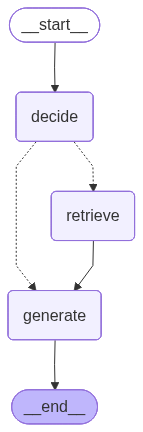

In [35]:
workflow=StateGraph(AgentState)

# add node(node_name, function)
workflow.add_node("decide", decide_retrieval)
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("generate", generate_answer)

workflow.set_entry_point("decide")

workflow.add_conditional_edges(
    "decide",
    should_retrieve,
    {
        "retrieve": "retrieve",
        "generate": "generate"
    }
)

workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate",END)

app=workflow.compile()
app

### Test the workflow

This function set the initial state and then invoke the workflow and returns the respective answer

In [36]:
def ask_question(question: str):
  initial_state={
      "question": question,
      "answer": "",
      "documents": [],
      "needs_retrieve": False
  }
  result=app.invoke(initial_state)
  return result

Try by giving a question

In [37]:
# Test with a question that should trigger retrieval
question1 = "What is LangGraph?"
result1 = ask_question(question1)
result1

{'question': 'What is LangGraph?',
 'answer': "LangGraph is an artificial intelligence (AI) model developed by Meta, designed to process and generate human-like language. It's a type of large language model (LLM) that uses natural language processing (NLP) to understand and respond to user input.\n\nLangGraph is trained on a massive dataset of text from various sources, including books, articles, and online conversations. This training enables the model to learn patterns, relationships, and structures of language, allowing it to generate coherent and contextually relevant text.\n\nThe capabilities of LangGraph include:\n\n1. **Text generation**: LangGraph can create text based on a given prompt, topic, or style.\n2. **Conversational dialogue**: The model can engage in natural-sounding conversations, using context and understanding to respond to questions and statements.\n3. **Language translation**: LangGraph can translate text from one language to another, leveraging its knowledge of 

In [38]:
# Test with another question
question2 = "How does RAG work?"
result2 = ask_question(question2)

print(f"Question: {question2}")
print(f"Retrieved documents: {len(result2['documents'])}")
print(f"Answer: {result2['answer']}")
print("\n" + "="*50 + "\n")

Question: How does RAG work?
Retrieved documents: 0
Answer: RAG (Retrieval-Augmented Generation) is a type of artificial intelligence (AI) model that combines the strengths of retrieval-based and generation-based approaches to produce more accurate and informative responses. Here's how it works:

**Overview**

RAG is a hybrid model that consists of two main components:

1. **Retriever**: This component is responsible for searching a large database or knowledge base to find relevant information related to the input query or prompt.
2. **Generator**: This component takes the retrieved information and uses it to generate a response.

**Step-by-Step Process**

Here's a step-by-step explanation of how RAG works:

1. **Input**: The user provides an input query or prompt.
2. **Retriever**: The retriever searches the database or knowledge base to find relevant information related to the input query. This is typically done using a similarity metric, such as cosine similarity or BM25.
3. **Retri